# Ex.No.2 - Linear Regression

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 28/01/2026_

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import zscore
from mpl_toolkits.mplot3d import Axes3D

# Simple Linear Regression

In [98]:
# Load only required columns
df = fetch_california_housing(as_frame=True).frame[["MedInc", "MedHouseVal"]]

# Outlier removal
df_clean = df[(np.abs(zscore(df)) < 3).all(axis=1)]
print("Original:", df.shape)
print("Clean:", df_clean.shape)

# Prepare data
X = df_clean[["MedInc"]]
y = df_clean["MedHouseVal"]

Original: (20640, 2)
Clean: (20295, 2)


In [99]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [100]:
# Parameters
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# Evaluation Metrics
y_pred = model.predict(X_test)

print("\nMODEL PERFORMANCE")
print("MAE  :", mean_absolute_error(y_test, y_pred))
print("MSE  :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2   :", r2_score(y_test, y_pred))


Intercept: 0.33404284867364264
Slope: 0.4505459673865368

MODEL PERFORMANCE
MAE  : 0.6288339967198677
MSE  : 0.706948836094509
RMSE : 0.8408024952951252
R2   : 0.4312553620145817


In [101]:
# New Data Prediction
x_new = np.array([[5.0]])  # Change anytime
print("Prediction for X =", x_new[0][0],
      "=> Y =", model.predict(x_new)[0])


Prediction for X = 5.0 => Y = 2.5867726856063267


C:\Users\Monish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


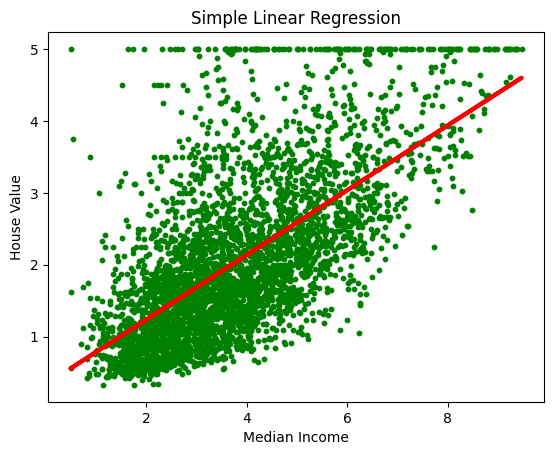

In [102]:
# Visualization

plt.figure()

# thinner scatter points
plt.scatter(X_test, y_test, s=10, color="green")

# thicker regression line
plt.plot(X_test, y_pred, linewidth=3, color="red")

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")

plt.show()


# Multiple Linear Regression

In [103]:
# Load Dataset
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Only BMI and BP
df = pd.concat([X[["bmi", "bp"]], y], axis=1)

df.head()

,bmi,bp,target
0,0.061696,0.021872,151.0
1,-0.051474,-0.026328,75.0
2,0.044451,-0.005670,141.0
3,-0.011595,-0.036656,206.0
4,-0.036385,0.021872,135.0


In [104]:
# Outlier Detection
z_scores = np.abs(zscore(df))
df_clean = df[(z_scores < 3).all(axis=1)]

print("Original size:", df.shape)
print("After outlier removal:", df_clean.shape)

# Split Features and Target
X_clean = df_clean[["bmi", "bp"]]
y_clean = df_clean["target"]

Original size: (442, 3)
After outlier removal: (440, 3)


In [105]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [106]:
# Parameters
print("Intercept:", model.intercept_)

print("\nSlopes:")
for feature, coef in zip(["bmi", "bp"], model.coef_):
    print(f"{feature} :", coef)


# Evaluation Metrics
y_pred = model.predict(X_test)

print("\nMAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


Intercept: 151.7213253859166

Slopes:
bmi : 786.2709502080926
bp : 401.33126161263687

MAE : 55.71546562370225
MSE : 4317.256432975336
RMSE: 65.70583256435715
R2  : 0.3368713760710118


In [107]:
# New Data Prediction
new_input = pd.DataFrame({
    "bmi": [0.03],
    "bp": [0.02]
})

prediction = model.predict(new_input)

print("Predicted Output:", prediction[0])


Predicted Output: 183.33607912441212


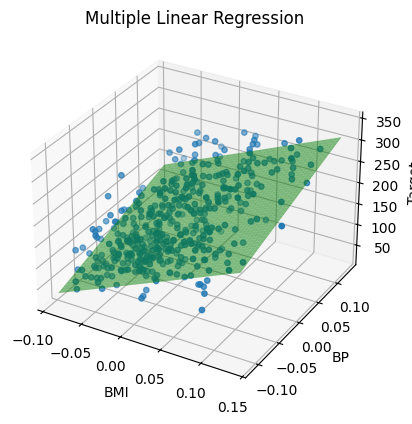

In [108]:
# Create grid for plane
bmi_vals, bp_vals = np.meshgrid(
    np.linspace(X_clean["bmi"].min(), X_clean["bmi"].max(), 50),
    np.linspace(X_clean["bp"].min(), X_clean["bp"].max(), 50)
)

# Predict plane values
grid = pd.DataFrame({
    "bmi": bmi_vals.ravel(),
    "bp": bp_vals.ravel()
})
z_vals = model.predict(grid).reshape(bmi_vals.shape)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(bmi_vals, bp_vals, z_vals, alpha=0.5, color="green")
ax.scatter(X_clean["bmi"], X_clean["bp"], y_clean, s=15)

ax.set_xlabel("BMI")
ax.set_ylabel("BP")
ax.set_zlabel("Target")
plt.title("Multiple Linear Regression")
plt.show()
